all 763291
day 1+ 756541
day 1+, warm only 738375
370202 landscape


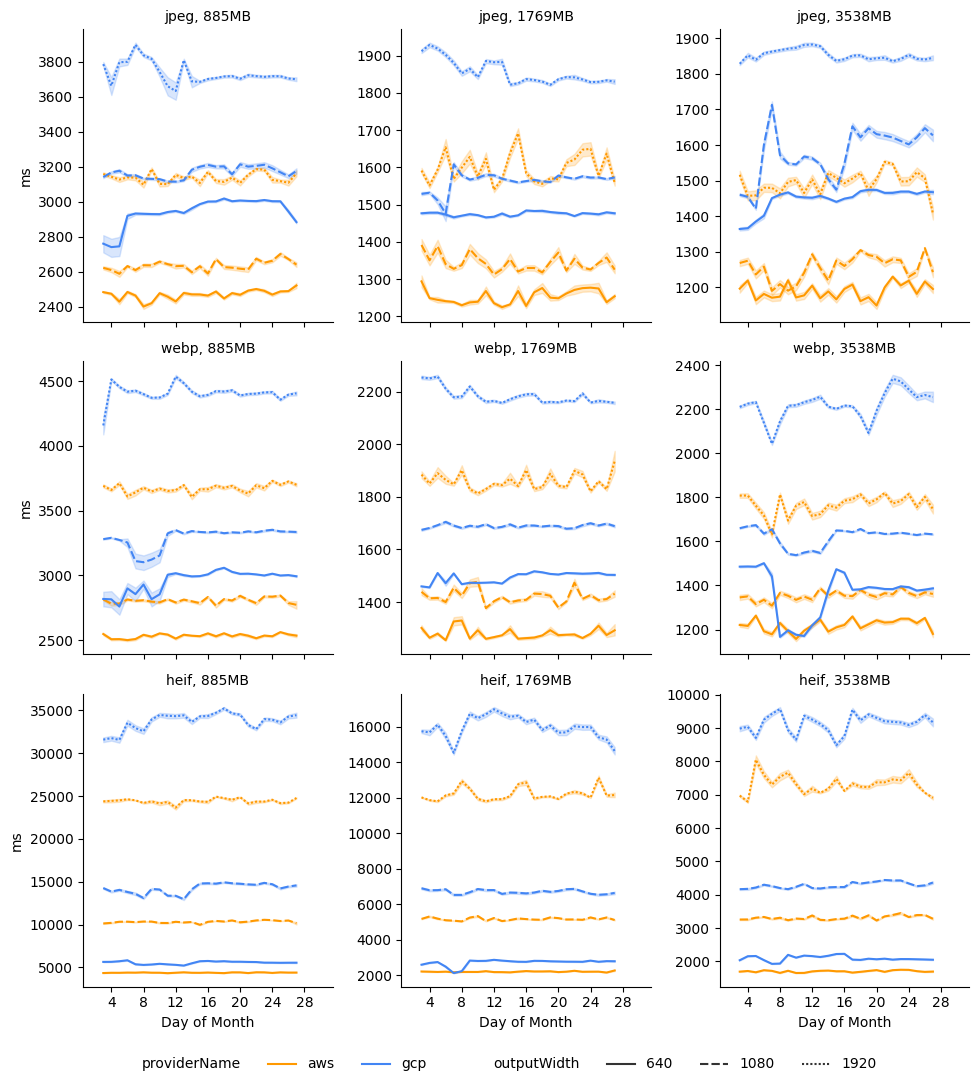

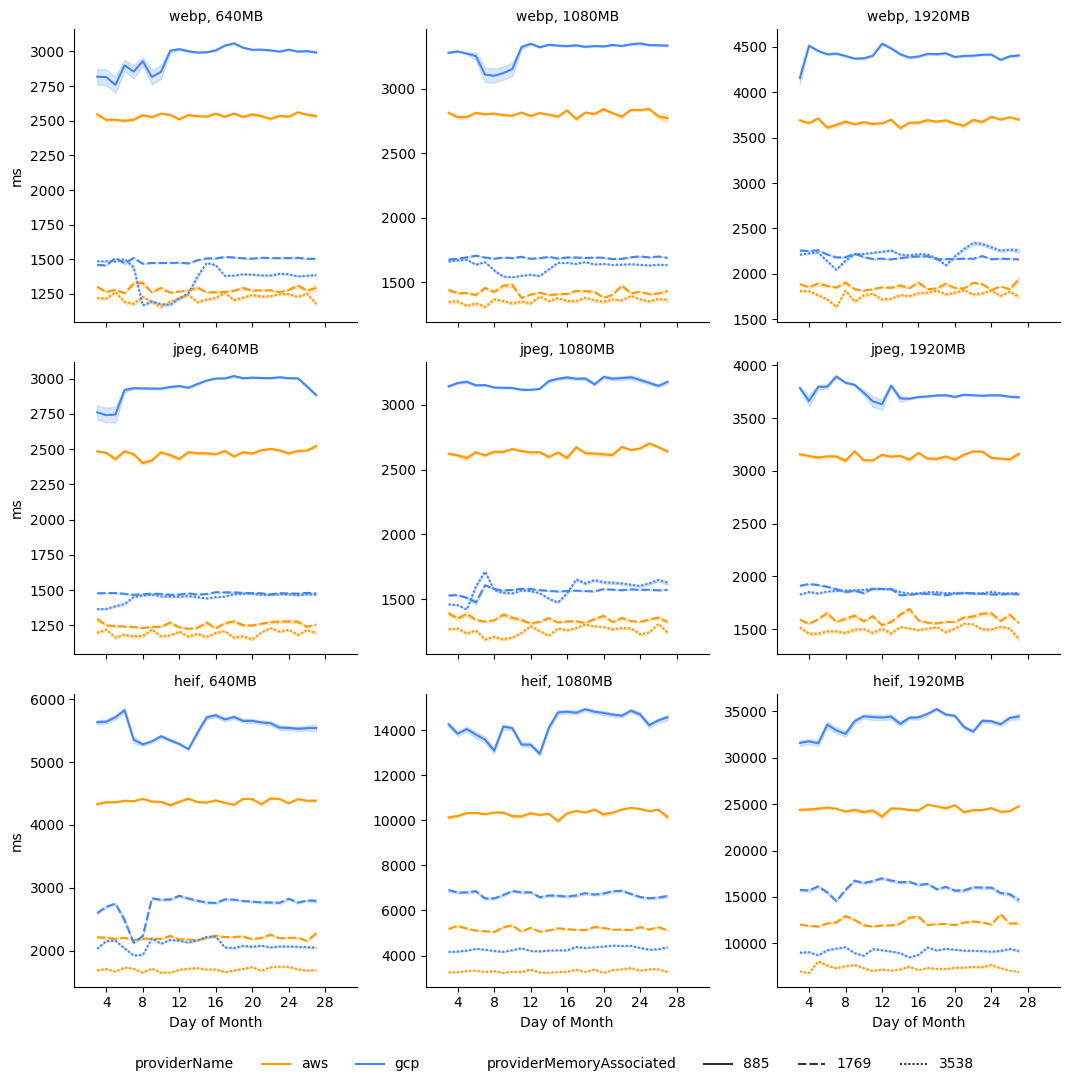

368173 portrait


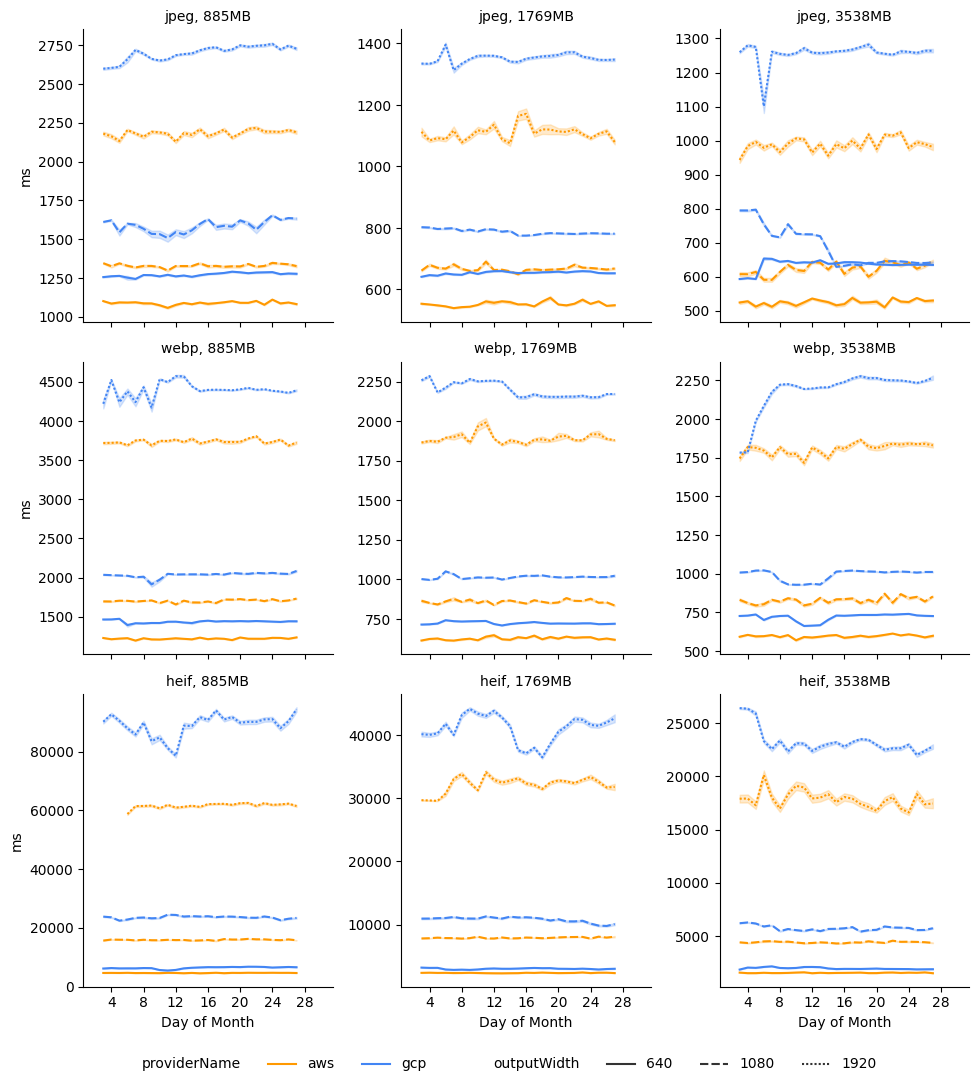

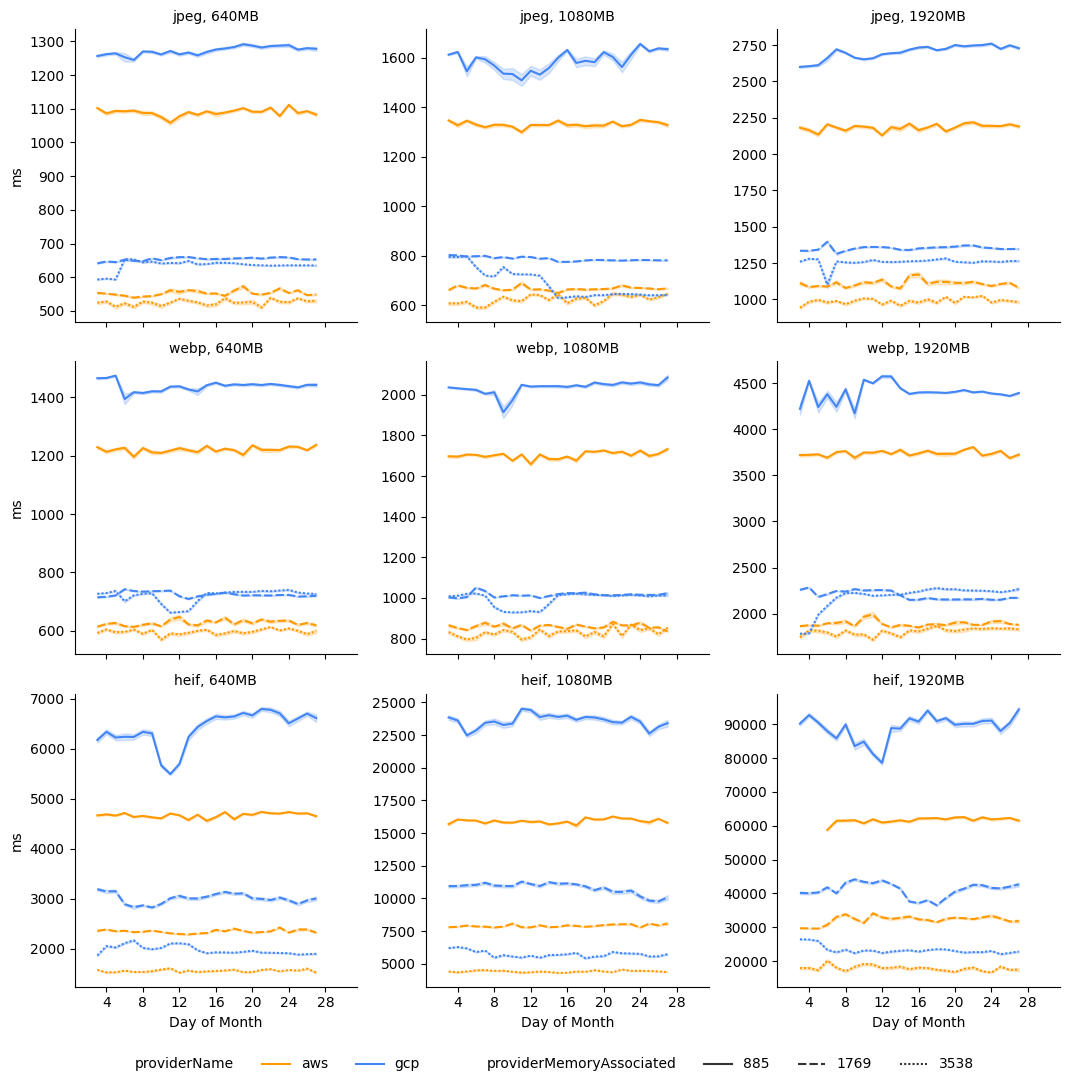

In [1]:
import pandas as pd
# import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.reset_defaults()
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
df = pd.read_pickle('../stats-all-latest.pkl')
print('all', len(df))

# Day 1+
data = df.loc[(df["timestamp"] > 1733184000000)].copy()
data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()
data["dom"] = data.index.day
data["dow"] = data.index.day_of_week
data["day_name"] = data.index.day_name()
data["day_name_short"] = data.index.strftime("%a")
data["hod"] = data.index.hour
data["moh"] = data.index.minute
data["how"] = data["dow"] * 24 + data["hod"]
data["msm"] = data.index.hour * 60 + (data.index.minute)
print('day 1+', len(data))

only_warm = data.loc[(data['coldStart'] != 1)]
print('day 1+, warm only', len(only_warm))

for imageName in ["landscape", "portrait"]:
    data2 = only_warm.loc[(only_warm["imageName"] == imageName)]
    print(len(data2), imageName)

    # data2 = data2.set_index('day_name_short')
    # data2 = data2.reindex(['M', 'Tu', 'W', 'Th', 'F', 'Sa', 'S'])

    g = sns.relplot(
        data=data2,
        kind='line',
        x='dom',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    g.set(xticks=range(0, 32, 4), xlim=(0.5, 31.5))
    g.set_titles("{row_name}, {col_name}MB")
    # g.set_xticklabels()
    g.set_xlabels('Day of Month')
    g.set_ylabels('ms')
    # plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

    g = sns.relplot(
        data=data2,
        kind='line',
        x='dom',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',    # Separate rows for each provider
        col='outputWidth',
        style='providerMemoryAssociated',
        # row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    g.set(xticks=range(0, 32, 4), xlim=(0.5, 31.5))
    g.set_titles("{row_name}, {col_name}MB")
    # g.set_xticklabels()
    g.set_xlabels('Day of Month')
    g.set_ylabels('ms')
    # plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

Day of Week

379361 landscape


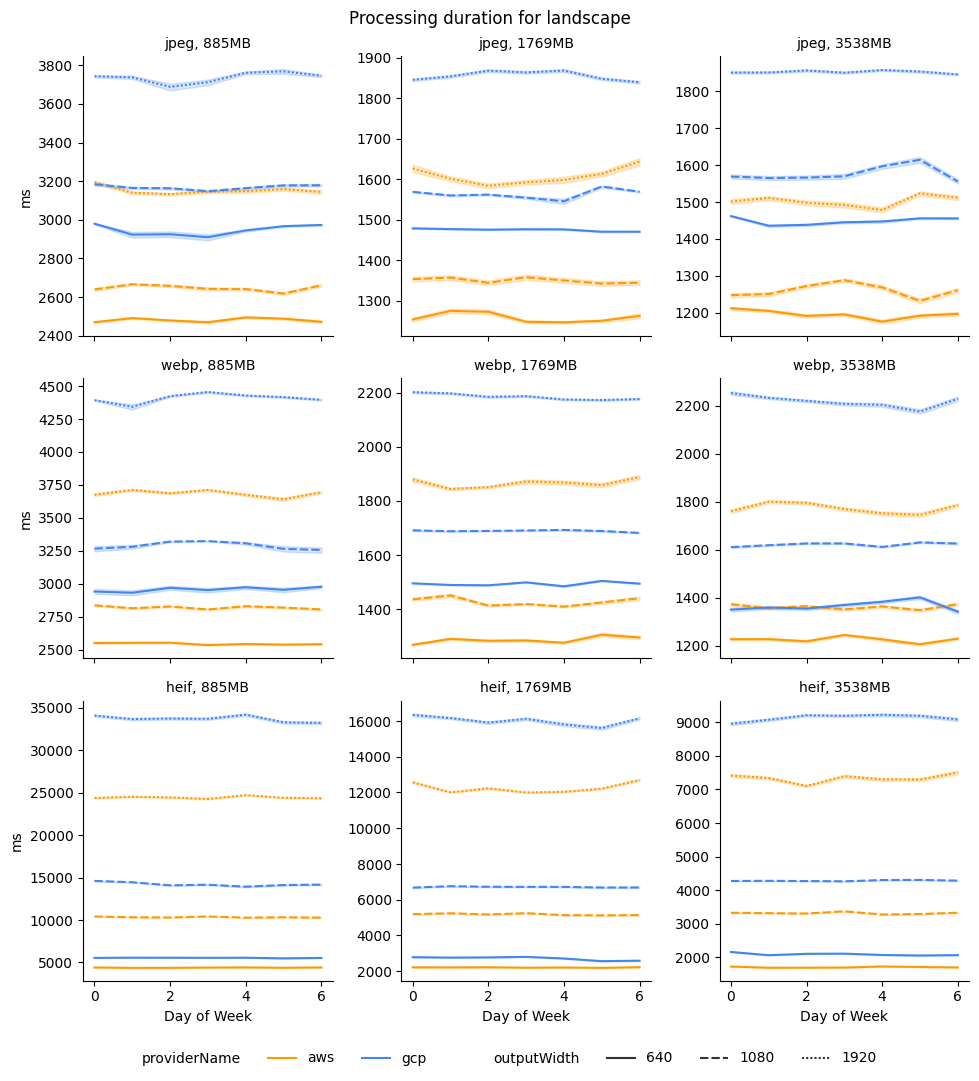

377180 portrait


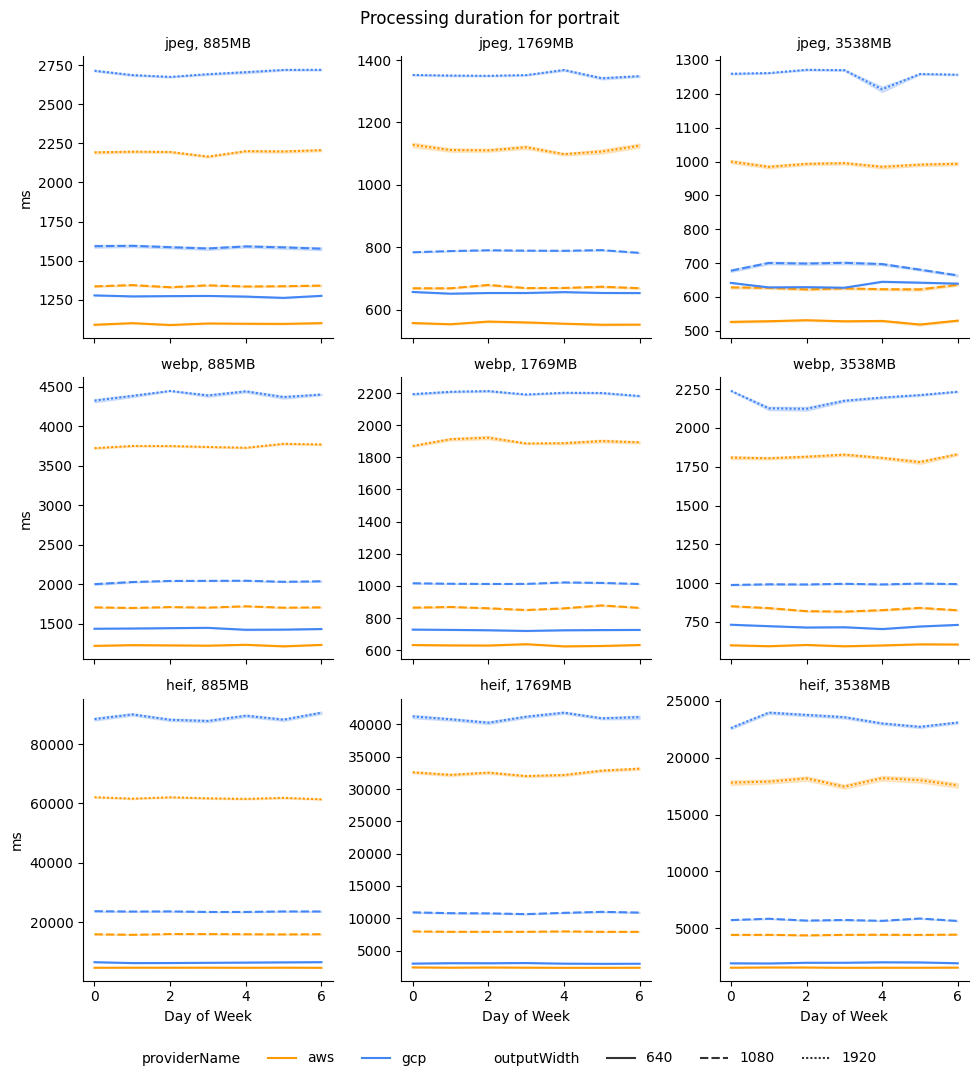

In [2]:
for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='dow',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Day of Week')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

## Hour of week

379361 landscape


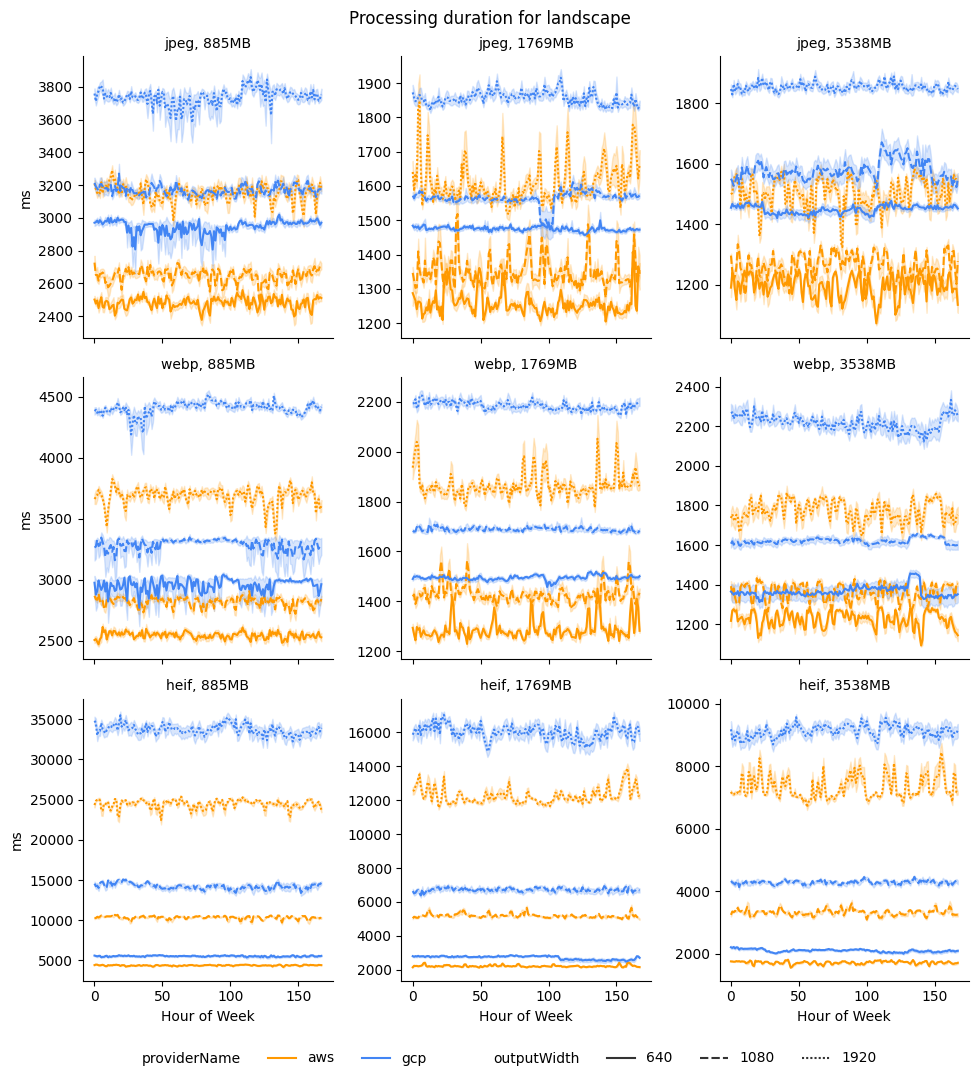

377180 portrait


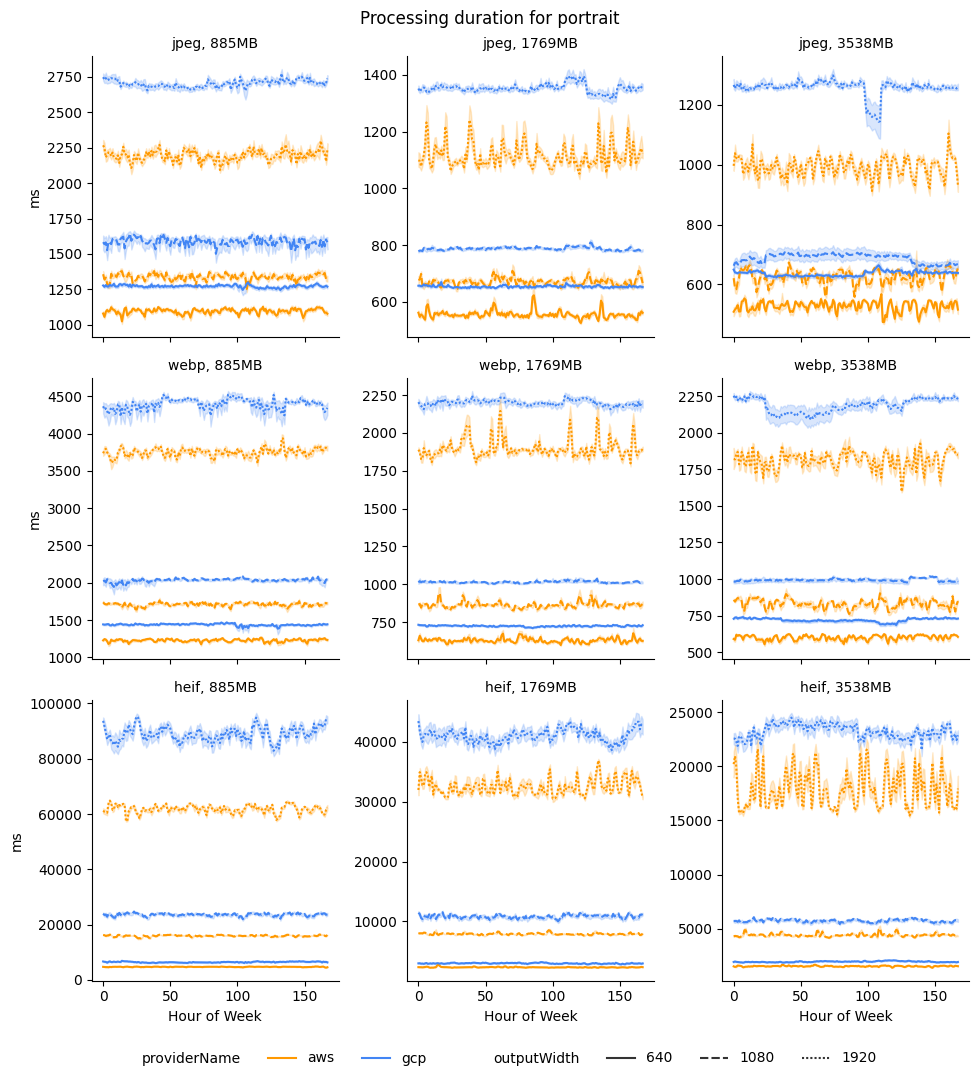

In [3]:
for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='how',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Week')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

756541
570325 weekdays only
286218 landscape


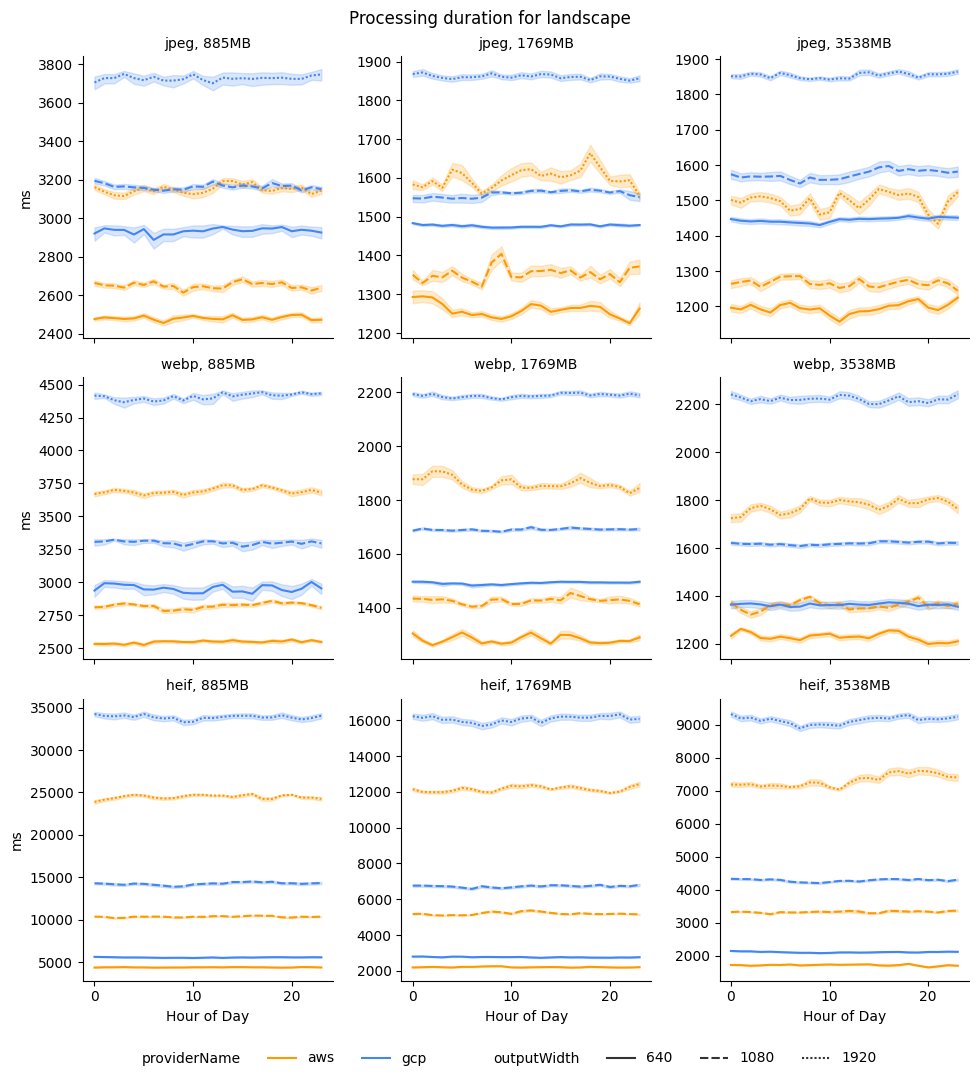

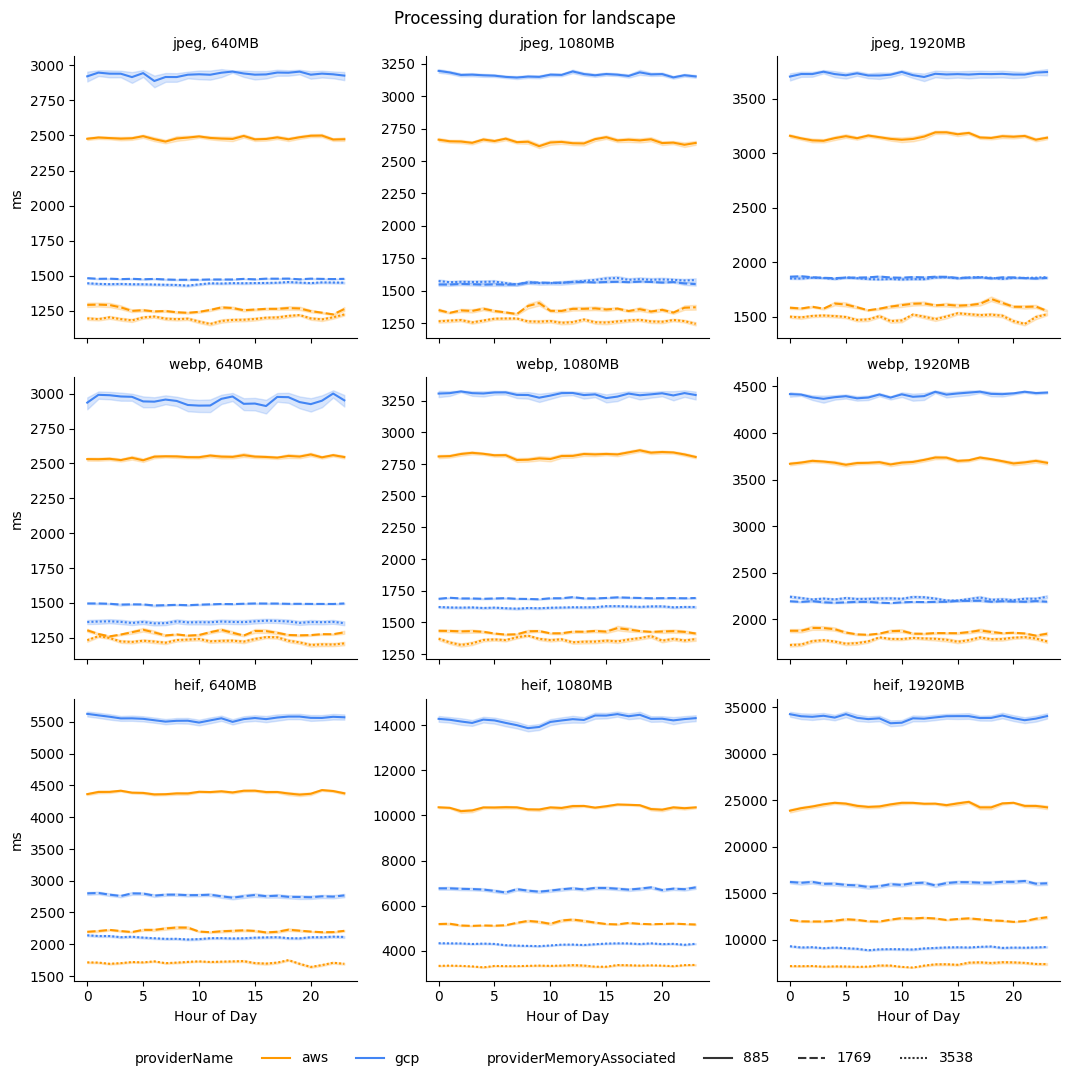

284107 portrait


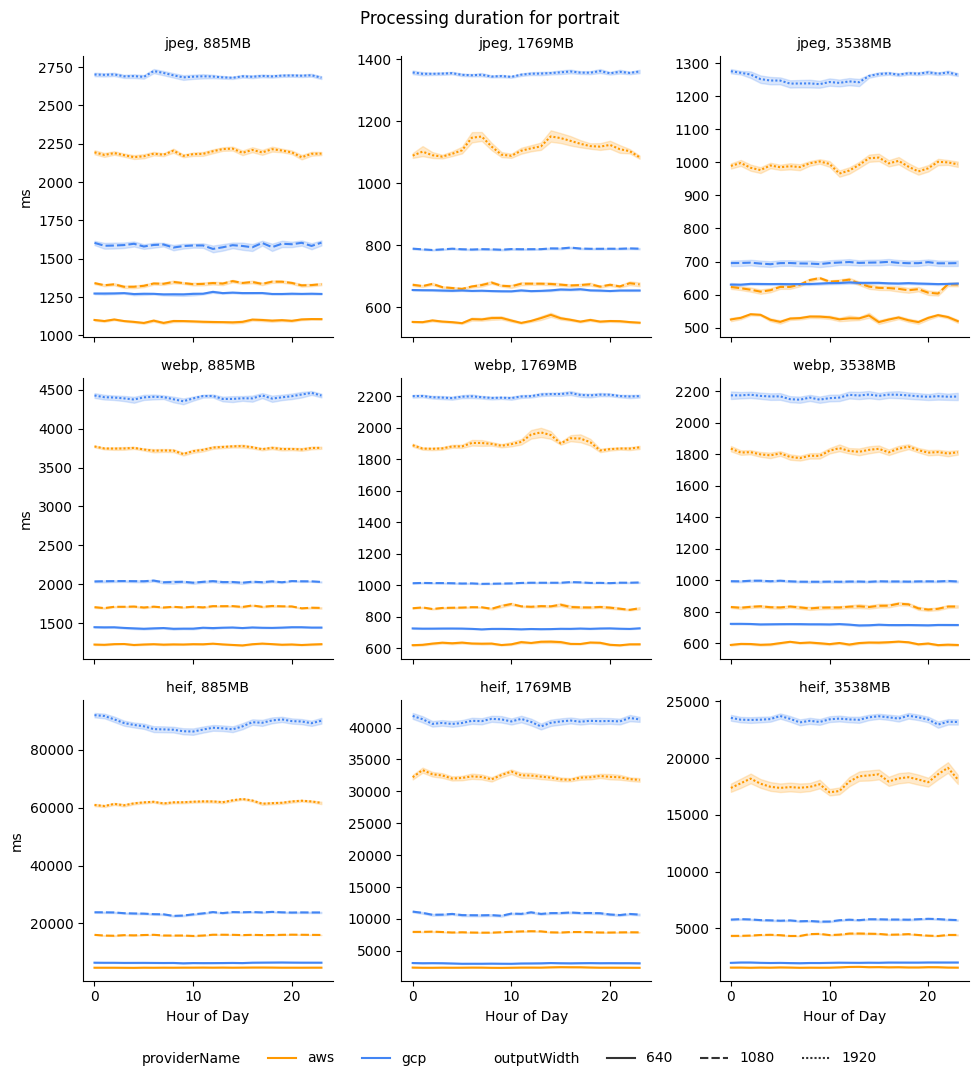

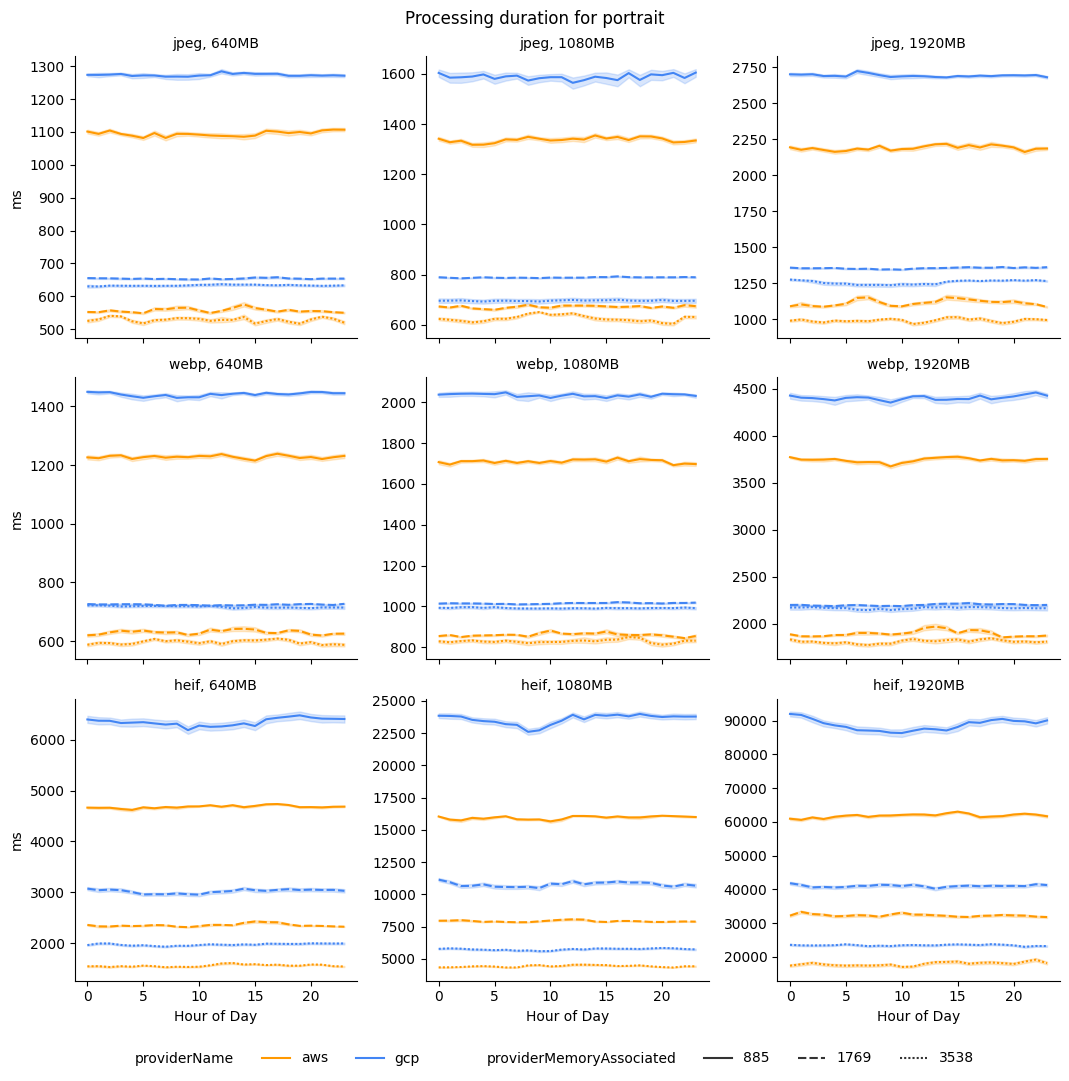

In [4]:
# remove weekends
print(len(data))
weekdays_only = data.loc[(data["dow"] != 5) & (data["dow"] != 6)]
print(len(weekdays_only), 'weekdays only')

for imageName in ["landscape", "portrait"]:
    data2 = weekdays_only.loc[(weekdays_only["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='hod',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

    g = sns.relplot(
        data=data2,
        kind='line',
        x='hod',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='outputWidth',
        style='providerMemoryAssociated',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

Minute since midnight

756541
570325 weekdays only
286218 landscape


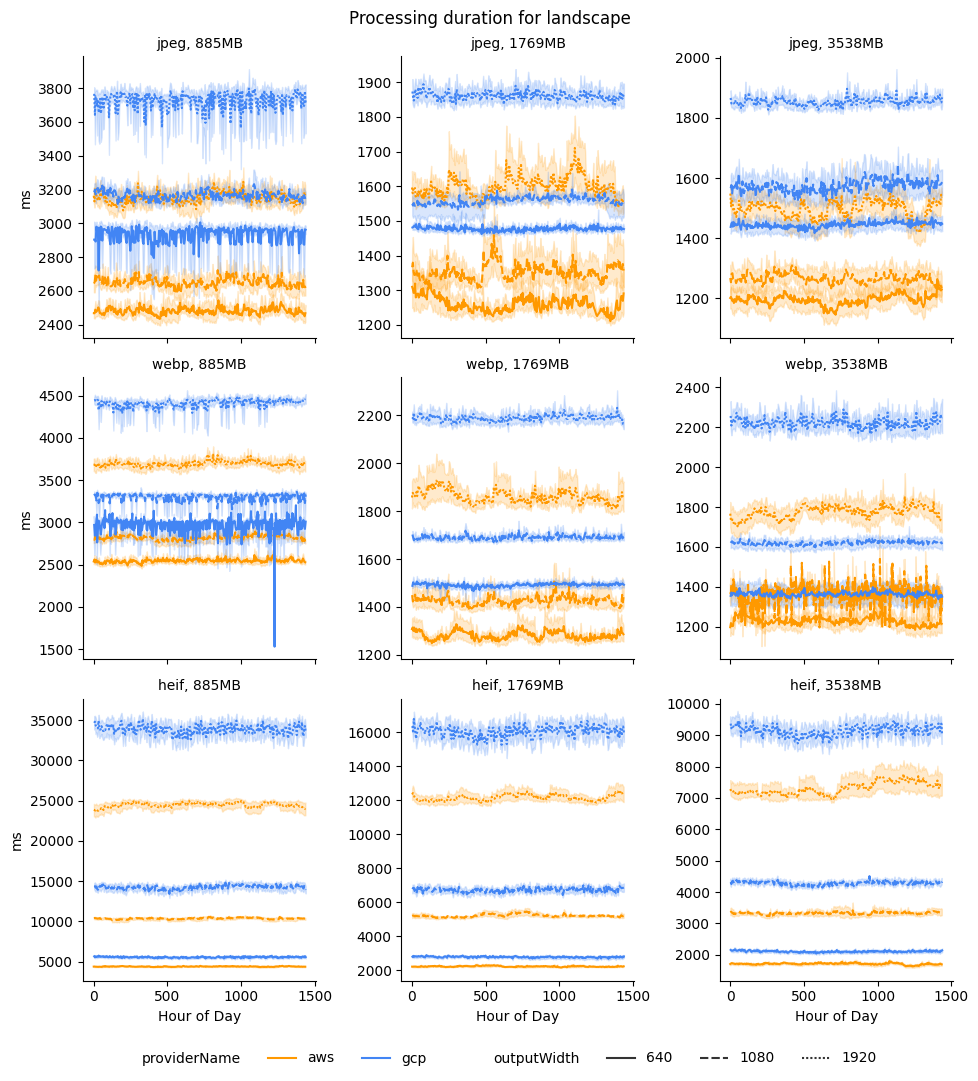

284107 portrait


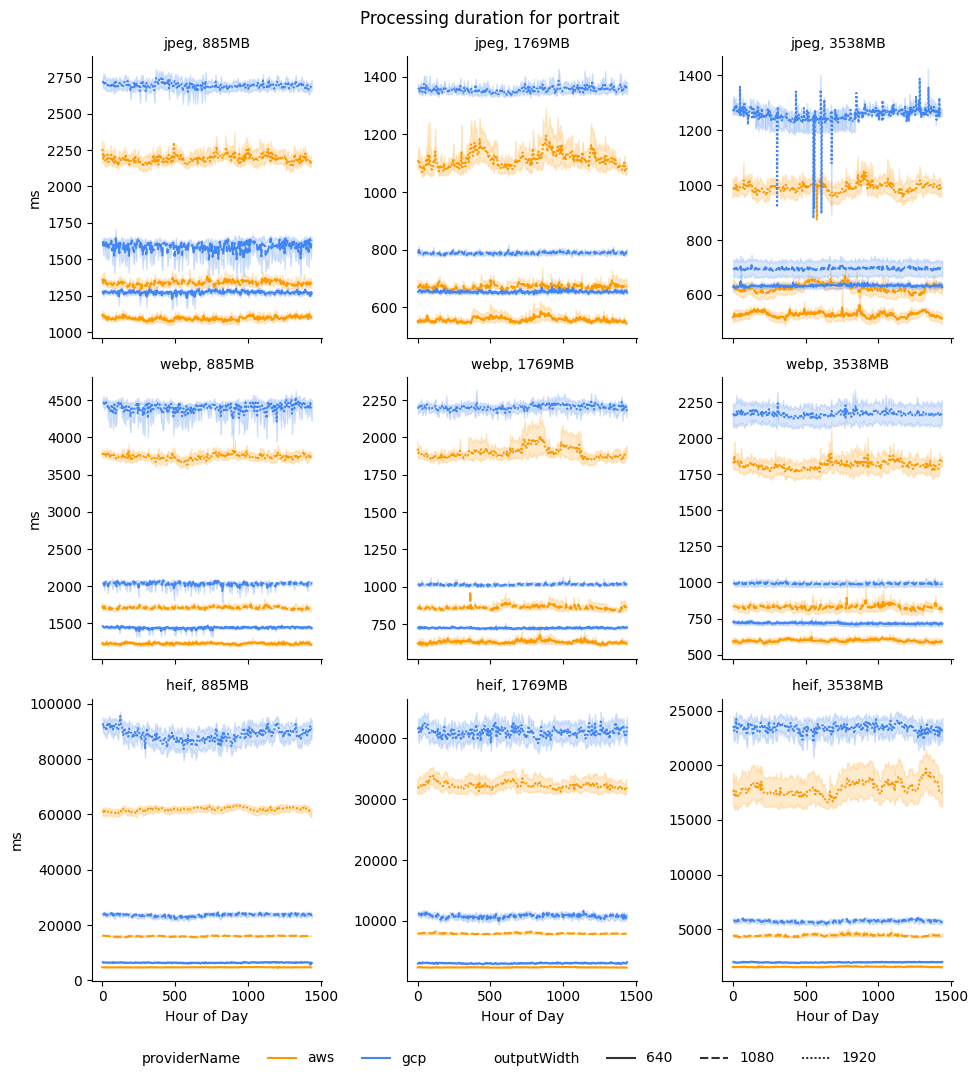

In [5]:
# remove weekends
print(len(data))
weekdays_only = data.loc[(data["dow"] != 5) & (data["dow"] != 6)]
print(len(weekdays_only), 'weekdays only')

for imageName in ["landscape", "portrait"]:
    data2 = weekdays_only.loc[(weekdays_only["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='msm',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()